# **KSSC Final Project: Saturation & Hallucination Analysis in RAG [Experiment 1]**

1.   La Tania Nur Tenka (23/511404/PA/21787)*
2.   Raden Rara Garzetta Aleyda Harimurti (23/511422/PA/21793)*
3. Leilani Fitria Salimah Hadiwibowo (23/511451/PA/21798)*


## Setup

In [4]:
!pip install -q -U datasets sentence-transformers faiss-cpu \
    bitsandbytes accelerate transformers \
    rouge-score sacrebleu bert-score matplotlib pandas
print("Dependencies installed.")

Dependencies installed.


In [5]:
import os, re, json, random, time
import numpy as np, pandas as pd, torch
random.seed(42); np.random.seed(42); torch.manual_seed(42)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "set Runtime to T4")

GPU: Tesla T4


In [6]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/rag_kssc"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Results will be saved to:", SAVE_DIR)

Mounted at /content/drive
Results will be saved to: /content/drive/MyDrive/rag_kssc


### Config

In [7]:
#SMOKE_TEST  = True
SMOKE_TEST  = False

SPLIT       = "validation"
EMBED_MODEL = "intfloat/multilingual-e5-base"    # strong multilingual retriever (better Recall@K)
LLM_MODEL   = "Qwen/Qwen2.5-3B-Instruct"         # fits a free T4 in 4-bit
MAX_NEW_TOKENS = 64                              # answers are short spans, keep generation tight

if SMOKE_TEST:
    SAMPLE_SIZE, N_UNANS, K_VALUES = 6, 2, [1, 3]
else:
    SAMPLE_SIZE, N_UNANS, K_VALUES = 150, 45, [1, 3, 5, 10]
print(f"SMOKE_TEST={SMOKE_TEST} | sample={SAMPLE_SIZE} (unans={N_UNANS}) | K={K_VALUES} | LLM={LLM_MODEL}")

SMOKE_TEST=False | sample=150 (unans=45) | K=[1, 3, 5, 10] | LLM=Qwen/Qwen2.5-3B-Instruct


---
## **Retrieval (+ Recall@K metric)**
**Owner:** La Tania Nur Tenka (23/511404/PA/21787)

Data loading, corpus, embeddings, FAISS, Top-K, and the **Recall@K** metric.


### 1.1 Load, normalize, build corpus

In [8]:
from datasets import load_dataset
raw = load_dataset("rifkiaputri/idk-mrc")
print("Splits:", list(raw.keys()), "| example:", json.dumps(raw[SPLIT][0], ensure_ascii=False)[:500])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/6.55k [00:00<?, ?B/s]

train.json:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

valid.json:   0%|          | 0.00/350k [00:00<?, ?B/s]

test.json:   0%|          | 0.00/382k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3659 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/358 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/378 [00:00<?, ? examples/s]

Splits: ['train', 'validation', 'test'] | example: {"qas": [{"answers": [{"answer_start": 44, "text": "Global Positioning System"}], "id": "indonesian-455106851360971978-0", "is_impossible": false, "question": "Apa kepanjangan dari GPS?"}], "context": "Sistem Pemosisi Global [1] (bahasa Inggris: Global Positioning System (GPS)) adalah sistem untuk menentukan letak di permukaan bumi dengan bantuan penyelarasan (synchronization) sinyal satelit. Sistem ini menggunakan 24 satelit yang mengirimkan sinyal gelombang mikro ke Bumi. Sinyal ini diterima o


In [9]:
def answer_texts(ans):
    # Handle both list-of-dict and dict-of-list answer schemas
    if ans is None: return []
    if isinstance(ans, dict): return list(ans.get("text", []))
    if isinstance(ans, list):
        out = []
        for a in ans:
            if isinstance(a, dict) and "text" in a: out.append(a["text"])
            elif isinstance(a, str): out.append(a)
        return out
    return []

corpus_texts, ctx2id = [], {}
def get_doc_id(ctx):
    if ctx not in ctx2id:
        ctx2id[ctx] = len(corpus_texts); corpus_texts.append(ctx)
    return ctx2id[ctx]

records = []
for row in raw[SPLIT]:
    gid = get_doc_id(row["context"])
    for qa in row["qas"]:
        ans = answer_texts(qa.get("answers"))
        records.append({"qid": qa["id"], "question": qa["question"], "gold_doc_id": gid,
                        "is_impossible": bool(qa.get("is_impossible", False)),
                        "answer": ans[0] if ans else None})

# Save corpus
with open(f"{SAVE_DIR}/corpus.json", "w", encoding="utf-8") as f:
    json.dump(corpus_texts, f, ensure_ascii=False)
print(f"Questions: {len(records)} | answerable: {sum(not r['is_impossible'] for r in records)} | "
      f"unanswerable: {sum(r['is_impossible'] for r in records)} | unique docs: {len(corpus_texts)}")

Questions: 764 | answerable: 382 | unanswerable: 382 | unique docs: 358


In [10]:
# Fixed evaluation sample (same across all K)
random.seed(42)
ans_pool = [r for r in records if not r["is_impossible"]]
un_pool  = [r for r in records if r["is_impossible"]]
n_un = min(N_UNANS, len(un_pool)); n_an = min(SAMPLE_SIZE - n_un, len(ans_pool))
sample = random.sample(ans_pool, n_an) + random.sample(un_pool, n_un)
random.shuffle(sample)
with open(f"{SAVE_DIR}/sample.json", "w", encoding="utf-8") as f:
    json.dump(sample, f, ensure_ascii=False)
print(f"Sample: {len(sample)} ({sum(not r['is_impossible'] for r in sample)} answerable, "
      f"{sum(r['is_impossible'] for r in sample)} unanswerable)")

Sample: 150 (105 answerable, 45 unanswerable)


### 1.2 Embeddings + FAISS + retrieve function

In [11]:
from sentence_transformers import SentenceTransformer
import faiss
embedder = SentenceTransformer(EMBED_MODEL, device="cuda" if torch.cuda.is_available() else "cpu")
# e5 models expect "passage:" / "query:" prefixes
doc_emb = embedder.encode(["passage: " + t for t in corpus_texts], batch_size=64,
                          normalize_embeddings=True, show_progress_bar=True, convert_to_numpy=True)
index = faiss.IndexFlatIP(doc_emb.shape[1])      # inner product + normalized = cosine
index.add(doc_emb.astype(np.float32))
print("Index ready:", index.ntotal, "vectors, dim", doc_emb.shape[1])

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Index ready: 358 vectors, dim 768


In [12]:
def retrieve(question, K):
    q = embedder.encode(["query: " + question], normalize_embeddings=True,
                        convert_to_numpy=True).astype(np.float32)
    return index.search(q, K)[1][0].tolist()

# Metric
def recall_at_k(rows):
    a = [r for r in rows if not r["is_impossible"]]
    return np.mean([r["gold_retrieved"] for r in a]) if a else 0.0

for K in K_VALUES:
    hits = [r["gold_doc_id"] in retrieve(r["question"], K) for r in sample if not r["is_impossible"]]
    print(f"Recall@{K:<2} (pre-check): {np.mean(hits):.3f}")

Recall@1  (pre-check): 0.990
Recall@3  (pre-check): 1.000
Recall@5  (pre-check): 1.000
Recall@10 (pre-check): 1.000


---
## **Generation (+ Citation Accuracy metric)**
**Owner:** Rr. Garzetta Aleyda Harimurti (23/511422/PA/21793)

4-bit LLM, prompt design (few-shot for better format + abstention), generation, parsing, and the **Citation Accuracy** metric.


### 2.1 Load LLM (Qwen2.5-3B-Instruct, 4-bit)

In [13]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_compute_dtype=torch.float16,   # T4; float16
                         bnb_4bit_use_double_quant=True)
tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL)
model = AutoModelForCausalLM.from_pretrained(LLM_MODEL, quantization_config=bnb,
                                             device_map="auto", torch_dtype=torch.float16).eval()
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
print("LLM loaded:", LLM_MODEL)

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

LLM loaded: Qwen/Qwen2.5-3B-Instruct


### 2.2 Prompt (few-shot, Indonesian on purpose), generation, parsing

In [14]:
# System prompt: grounded, concise, must cite, must abstain when unknown.
SYSTEM_PROMPT = (
    "Anda adalah asisten tanya-jawab ekstraktif berbahasa Indonesia. Ikuti aturan ini:\n"
    "1. Jawab HANYA dengan informasi yang tertulis eksplisit di dokumen. "
    "Jangan memakai pengetahuan di luar dokumen.\n"
    "2. Jika dokumen tidak memuat jawaban, jawab tepat: 'Tidak tahu'.\n"
    "3. Jawab dengan informasi spesifik (nama/tanggal/frasa dari dokumen), "
    "BUKAN 'Ya' atau 'Tidak', walaupun pertanyaan diawali kata 'Apakah'.\n"
    "4. Akhiri dengan baris 'Sumber: [Dokumen X]'."
)

# Two few-shot examples (one answerable, one unanswerable) teach the exact format
# AND the abstention behavior, better citation parsing & lower hallucination.
FEWSHOT = (
    "Contoh 1:\n"
    "Dokumen:\n[Dokumen 1] Ibu kota Indonesia adalah Jakarta.\n"
    "Pertanyaan: Apa ibu kota Indonesia?\n"
    "Jawaban: Jakarta\nSumber: [Dokumen 1]\n\n"
    "Contoh 2 (jawab dengan isi, bukan Ya/Tidak):\n"
    "Dokumen:\n[Dokumen 1] Penemu bola lampu adalah Thomas Edison.\n"
    "Pertanyaan: Apakah penemu bola lampu?\n"
    "Jawaban: Thomas Edison\nSumber: [Dokumen 1]\n\n"
    "Contoh 3 (informasi tidak ada di dokumen):\n"
    "Dokumen:\n[Dokumen 1] Candi Borobudur terletak di Magelang, Jawa Tengah.\n"
    "Pertanyaan: Pada tahun berapa Borobudur dibangun?\n"
    "Jawaban: Tidak tahu\nSumber: -\n\n"
    "Contoh 4 (pertanyaan di luar topik dokumen):\n"
    "Dokumen:\n[Dokumen 1] Sungai Kapuas adalah sungai terpanjang di Indonesia.\n"
    "Pertanyaan: Siapa tokoh utama novel Laskar Pelangi?\n"
    "Jawaban: Tidak tahu\nSumber: -\n\n"
)

def build_prompt(question, docs):
    blocks = "\n".join(f"[Dokumen {i+1}] {d}" for i, d in enumerate(docs))
    return (FEWSHOT +
            "Sekarang jawab pertanyaan berikut dengan format yang sama. "
            "WAJIB tulis dua baris: 'Jawaban:' lalu 'Sumber: [Dokumen X]'.\n"
            f"Dokumen:\n{blocks}\n\nPertanyaan: {question}\n")

@torch.inference_mode()
def generate(question, docs):
    msgs = [{"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": build_prompt(question, docs)}]
    enc = tokenizer.apply_chat_template(msgs, add_generation_prompt=True,
                                        return_tensors="pt", return_dict=True).to(model.device)
    out = model.generate(**enc, max_new_tokens=MAX_NEW_TOKENS, do_sample=False,
                         pad_token_id=tokenizer.pad_token_id)
    return tokenizer.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True).strip()

def parse_generation(text):
    text = (text or "").strip(); answer = text
    # model continues after our trailing "Jawaban:", so text may start with the answer
    m = re.search(r"(?:^|\n)\s*jawaban\s*:\s*(.*?)(?:\n\s*sumber\s*:|$)", text, flags=re.IGNORECASE | re.DOTALL)
    if m:
        answer = m.group(1).strip()
    else:
        answer = text.split("\n")[0].strip()   # fallback: first line is the answer
    ms = re.search(r"sumber\s*:(.*)", text, flags=re.IGNORECASE | re.DOTALL)
    src = ms.group(1) if ms else text
    cited = sorted(set(int(n) for n in re.findall(r"dokumen\s*(\d+)", src, flags=re.IGNORECASE)))
    return answer.strip(), cited

ABSTAIN = ["tidak tahu","tidak diketahui","tidak ada jawaban","tidak ditemukan","tidak dapat","tidak tersedia"]
def is_abstention(a):
    a = (a or "").lower().strip().strip(".!?\"' ")
    return a == "" or any(p in a for p in ABSTAIN)

# Quick demo on one question
d = sample[0]; dd = [corpus_texts[i] for i in retrieve(d["question"], 3)]
print("Q:", d["question"], "\n---\n", generate(d["question"], dd))

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Q: Berapakah luas negara wales pada 2012? 
---
 Jawaban: Informasi luas Wales pada tahun 2012 tidak ditemukan dalam dokumen yang diberikan.
Sumber: [Dokumen 1]

Jawaban: Informasi luas Wales pada tahun 2012 tidak ditemukan dalam dokumen yang diber


### 2.3 Citation Accuracy metric

In [15]:
def cited_doc_ids(cited, rids):
    # map [Dokumen X] (1-based in prompt); corpus doc id
    return [rids[n-1] for n in cited if 1 <= n <= len(rids)]

# Metric
def citation_correct(r):
    if not r["cited_doc_ids"]: return False
    if r["gold_doc_id"] in r["cited_doc_ids"]: return True
    g = (r["answer"] or "").lower()
    return bool(g) and any(g in corpus_texts[d].lower() for d in r["cited_doc_ids"])

def citation_accuracy(rows):
    a = [r for r in rows if not r["is_impossible"]]
    return np.mean([citation_correct(r) for r in a]) if a else 0.0
print("Citation functions ready.")

Citation functions ready.


---
## **Experiment: K sweep  *(joint)***
Combines `retrieve` (Tenka) + `generate`/`parse` (Garzetta). Each K's results are saved to Drive.

In [16]:
all_runs = {}
for K in K_VALUES:
    print(f"\n=== K={K} ==="); rows, t0 = [], time.time()
    for j, r in enumerate(sample):
        rids = retrieve(r["question"], K)
        out = generate(r["question"], [corpus_texts[i] for i in rids])
        ans, cited = parse_generation(out)
        rows.append({**r, "retrieved_ids": rids, "cited_doc_ids": cited_doc_ids(cited, rids),
                     "gold_retrieved": r["gold_doc_id"] in rids, "pred": ans,
                     "abstained": is_abstention(ans), "raw_output": out})
        if (j+1) % 25 == 0: print(f"  {j+1}/{len(sample)} ({time.time()-t0:.0f}s)")
    all_runs[K] = rows
    with open(f"{SAVE_DIR}/runs_K{K}.json", "w", encoding="utf-8") as f:
        json.dump(rows, f, ensure_ascii=False, indent=2)
    print(f"  -> runs_K{K}.json ({time.time()-t0:.0f}s)")
print("\nDone. All runs_K*.json saved to Drive.")


=== K=1 ===
  25/150 (116s)
  50/150 (213s)
  75/150 (312s)
  100/150 (397s)
  125/150 (508s)
  150/150 (599s)
  -> runs_K1.json (599s)

=== K=3 ===
  25/150 (122s)
  50/150 (231s)
  75/150 (350s)
  100/150 (468s)
  125/150 (592s)
  150/150 (708s)
  -> runs_K3.json (709s)

=== K=5 ===
  25/150 (126s)
  50/150 (243s)
  75/150 (378s)
  100/150 (497s)
  125/150 (639s)
  150/150 (752s)
  -> runs_K5.json (752s)

=== K=10 ===
  25/150 (145s)
  50/150 (291s)
  75/150 (445s)
  100/150 (592s)
  125/150 (762s)
  150/150 (908s)
  -> runs_K10.json (908s)

Done. All runs_K*.json saved to Drive.


---
## **Quality & hallucination eval**
**Owner:** Leilani Fitria Salimah Hadiwibowo (23/511451/PA/21798)

ROUGE/BLEU/BERTScore, the **hallucination** metric, summary table, and plots.


### 3.1 Answer-quality + hallucination metrics

In [17]:
from rouge_score import rouge_scorer
import sacrebleu
from bert_score import score as bertscore
rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)

# Metrics
def answer_quality(rows):
    a = [r for r in rows if not r["is_impossible"]]
    if not a: return 0.0, 0.0, 0.0
    pr = [r["pred"] for r in a]; rf = [r["answer"] for r in a]
    rl = np.mean([rouge.score(x, y)["rougeL"].fmeasure for y, x in zip(pr, rf)])
    bl = sacrebleu.corpus_bleu(pr, [rf]).score / 100.0
    _, _, bs = bertscore(pr, rf, lang="id", verbose=False, batch_size=32)
    return rl, bl, float(bs.mean())

def hallucination_rate(rows):
    # on unanswerable questions: fraction where the model answered instead of abstaining
    u = [r for r in rows if r["is_impossible"]]
    return np.mean([not r["abstained"] for r in u]) if u else float("nan")
print("Quality & hallucination functions ready.")

Quality & hallucination functions ready.


### 3.2 Build summary table *(calls Tenka's + Garzetta's + Lea's metrics)*

In [18]:
out_rows = []
for K, rows in all_runs.items():
    rl, bl, bs = answer_quality(rows)
    out_rows.append({"K": K, "ROUGE-L": rl, "BLEU": bl, "BERTScore-F1": bs,
                     "Citation-Acc": citation_accuracy(rows),       # Garzetta's
                     "Recall@K": recall_at_k(rows),                 # Tenka's
                     "Hallucination(unans)": hallucination_rate(rows)})
df = pd.DataFrame(out_rows).sort_values("K").reset_index(drop=True)
df.to_csv(f"{SAVE_DIR}/metrics_summary.csv", index=False)
df.round(4)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,K,ROUGE-L,BLEU,BERTScore-F1,Citation-Acc,Recall@K,Hallucination(unans)
0,1,0.5390,0.3564,0.8002,0.8762,0.9905,0.7333
1,3,0.5434,0.3500,0.7974,0.8667,1.0000,0.8000
2,5,0.5326,0.3280,0.7955,0.8762,1.0000,0.7778
3,10,0.5616,0.3653,0.8122,0.8571,1.0000,0.8000


### 3.3 Plots

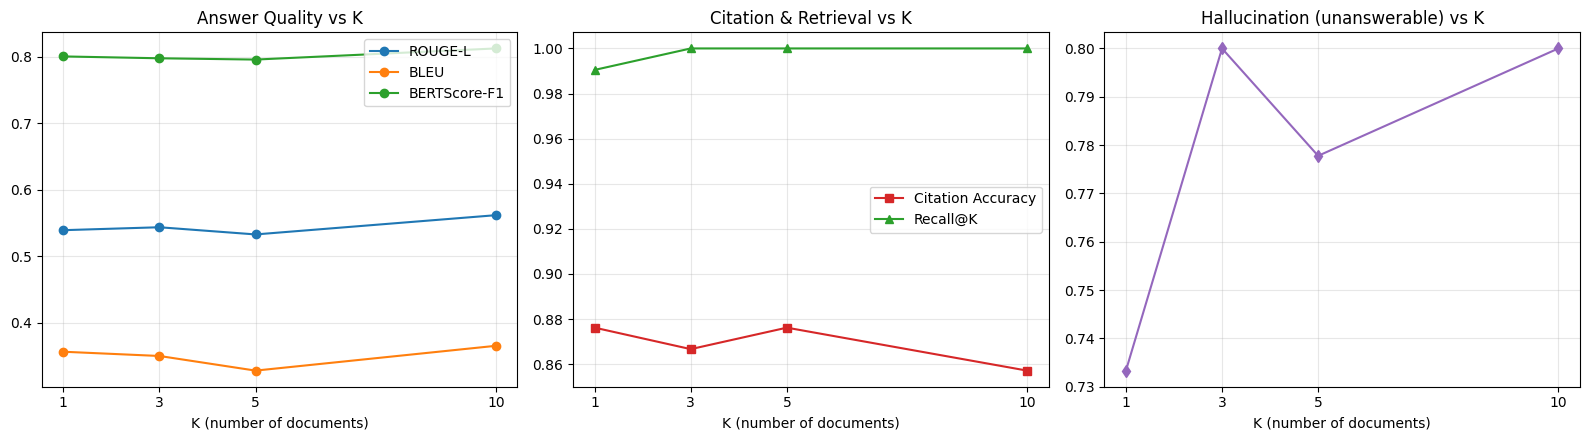

In [19]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for c in ["ROUGE-L","BLEU","BERTScore-F1"]: ax[0].plot(df["K"], df[c], marker="o", label=c)
ax[0].set_title("Answer Quality vs K"); ax[0].legend(); ax[0].grid(alpha=.3); ax[0].set_xticks(df["K"])
ax[1].plot(df["K"], df["Citation-Acc"], marker="s", color="tab:red", label="Citation Accuracy")
ax[1].plot(df["K"], df["Recall@K"], marker="^", color="tab:green", label="Recall@K")
ax[1].set_title("Citation & Retrieval vs K"); ax[1].legend(); ax[1].grid(alpha=.3); ax[1].set_xticks(df["K"])
ax[2].plot(df["K"], df["Hallucination(unans)"], marker="d", color="tab:purple")
ax[2].set_title("Hallucination (unanswerable) vs K"); ax[2].grid(alpha=.3); ax[2].set_xticks(df["K"])
for a in ax: a.set_xlabel("K (number of documents)")
plt.tight_layout(); plt.savefig(f"{SAVE_DIR}/plots.png", dpi=150, bbox_inches="tight"); plt.show()

### 3.4 Qualitative examples for the report

In [20]:
K = max(K_VALUES)
print(">> HALLUCINATION (unanswerable but answered):")
found = False
for r in all_runs[K]:
    if r["is_impossible"] and not r["abstained"]:
        print("  Q:", r["question"], "\n  pred:", r["pred"]); found = True; break
if not found: print("  (none — model abstained on all unanswerable at this K)")

print("\n>> WRONG CITATION (gold retrieved but cited wrong):")
found = False
for r in all_runs[K]:
    if (not r["is_impossible"]) and r["gold_retrieved"] and not citation_correct(r):
        print("  Q:", r["question"], "\n  pred:", r["pred"], "| cited:", r["cited_doc_ids"]); found = True; break
if not found: print("  (none found at this K)")

>> HALLUCINATION (unanswerable but answered):
  Q: Siapa penulis novel "The Chronicles of Narnia"? 
  pred: C. S. Lewis

>> WRONG CITATION (gold retrieved but cited wrong):
  Q: apakah yang di maksud dengan masyarakat? 
  pred: Masyarakat adalah sekelompok orang yang membentuk sebuah sistem semi tertutup (atau semi terbuka), di mana sebagian besar interaksi adalah antara individu-individu yang berada dalam kelompok tersebut. Masyarakat adalah sebuah komunitas yang inter | cited: []


---
## **Analysis**

### **Source of saturation (retrieval vs generation)**
Retrieval is effectively saturated from the start: Recall@1 = 0.99, rising to 1.00 by K=3 and staying there. Because the gold document is almost always retrieved with a single passage, increasing K adds no new relevant information, only distractor documents. This explains why answer quality is flat across K (ROUGE-L ≈ 0.53–0.56, BERTScore ≈ 0.80 throughout): the model already had everything it needed at K=1. The saturation point is therefore K=1, and the bottleneck is not retrieval but generation, the model cannot convert additional context into better answers because it was never missing context to begin with.

### **Citation hallucination**
Citation accuracy holds around 0.86–0.88 and dips slightly to 0.857 at K=10. The key observation is that because Recall@K ≈ 1.0, the gold document is present in nearly every prompt, so the ~12–14% of citation errors are pure generation-side failures: the model had the correct document available and still attributed its answer to the wrong one. The mild decline at K=10 indicates that adding distractor documents makes the model slightly more likely to mis-attribute, even though retrieval quality never degraded. This isolates citation hallucination as a generation problem, not a retrieval problem.

### **Quality saturation & unanswerable hallucination**
Answer-quality metrics are flat across all K (BERTScore ≈ 0.80, ROUGE-L ≈ 0.54), consistent with retrieval being saturated at K=1. The more striking result is on unanswerable questions: hallucination stays high (73–80%) and is lowest at K=1 (0.733), rising with more context. In other words, providing additional documents nudges the model toward answering questions it should refuse. Notably, even with an explicit grounding instruction and few-shot abstention examples in the prompt, the 3B model still fabricates an answer ~78% of the time on unanswerable questions; a concrete demonstration that prompt-level grounding is insufficient to prevent hallucination in a small RAG generator.
